# Cross-Border Arbitrage Simulator

This notebook contains the main logic for the Cross-Border Arbitrage Simulator. It includes sections for importing libraries, fetching data, processing it, and visualizing results, all while using Shopify's ticker for demonstration purposes.

In [10]:
# 2) Cell 1: Imports and Global Parameters
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Parameters and fees
initial_capital = 10_000
cad_fee = 30              # flat CAD fee on CAD side
usd_fee_rate = 0.0003     # fee rate on USD side (converted to CAD)

# Company tickers
domestic_ticker = "SHOP.TO"   # TSX (CAD)
foreign_ticker = "SHOP"       # NYSE (USD)

# Time frame: 1 year ago → yesterday
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

print(f"Date window: {start_date.date()} to {end_date.date()}")

Date window: 2025-03-10 to 2026-03-10


In [11]:
# 3) Cell 2: Ticker Metadata Fetch
domestic_info = yf.Ticker(domestic_ticker).info
foreign_info = yf.Ticker(foreign_ticker).info

name = domestic_info.get("longName", "N/A")
industry = domestic_info.get("industry", "N/A")
sector = domestic_info.get("sector", "N/A")
location = f"{domestic_info.get('city', '')}, {domestic_info.get('country', '')}"
domestic_exchange = domestic_info.get("exchange", "N/A")
foreign_exchange = foreign_info.get("exchange", "N/A")

company_df = pd.DataFrame([{
    "name": name,
    "domestic_ticker": domestic_ticker,
    "industry": industry,
    "sector": sector,
    "location": location,
    "domestic_exchange": domestic_exchange,
    "foreign_exchange": foreign_exchange,
    "foreign_ticker": foreign_ticker
}])

print("Company / Exchange Info:")
display(company_df)

Company / Exchange Info:


,name,domestic_ticker,industry,sector,location,domestic_exchange,foreign_exchange,foreign_ticker
0,Shopify Inc.,SHOP.TO,Software - Application,Technology,"Ottawa, Canada",TOR,NMS,SHOP


In [12]:
# 4) Cell 3: FX Rate Helper Function and Data Pull
def get_rate(ex_ticker, start_date, end_date):
    ex_rate = yf.Ticker(ex_ticker)
    ex_hist = ex_rate.history(start=start_date, end=end_date)
    ex_df = pd.DataFrame({"Exchange Rate": ex_hist["Close"]})
    ex_df.index = pd.to_datetime(ex_df.index.date)  # normalize to date only
    return ex_df

exchange_df = get_rate("CADUSD=X", start_date, end_date)  # USD per 1 CAD
exchange_df.head()

,Exchange Rate
2025-03-10,0.695885
2025-03-11,0.693053
2025-03-12,0.692885
2025-03-13,0.696296
2025-03-14,0.693202


In [13]:
# 5) Cell 4: Price Download, Cleanup, and Merge
prices = yf.download(
    [domestic_ticker, foreign_ticker],
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.index = pd.to_datetime(prices.index.date)

prices = prices.rename(columns={
    domestic_ticker: "Close_domestic",   # CAD
    foreign_ticker: "Close_foreign"      # USD
})

# Merge with FX
merged = prices.join(exchange_df, how="inner")
merged["Exchange Rate"] = merged["Exchange Rate"].ffill()

# Implied CAD price of US side
merged["CAD_implied_close_price"] = merged["Close_foreign"] / merged["Exchange Rate"]

merged_portfolio = merged[[
    "Close_domestic",
    "CAD_implied_close_price",
    "Close_foreign",
    "Exchange Rate"
]].dropna().copy()

print("Merged portfolio preview:")
display(merged_portfolio.head())

[*********************100%***********************]  2 of 2 completed

Merged portfolio preview:


,Close_domestic,CAD_implied_close_price,Close_foreign,Exchange Rate
2025-03-10,133.929993,133.283596,92.750000,0.695885
2025-03-11,133.960007,134.116629,92.949997,0.693053
2025-03-12,138.839996,139.315954,96.529999,0.692885
2025-03-13,130.720001,130.102636,90.589996,0.696296
2025-03-14,136.330002,136.828715,94.849998,0.693202


In [14]:
# 6) Cell 5: Arbitrage Strategy Function
def buy_sell_compounding(df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    capital = float(initial_capital)
    dates, capitals, trades = [], [], []

    df = df.dropna(subset=[
        "Close_domestic",
        "CAD_implied_close_price",
        "Close_foreign",
        "Exchange Rate"
    ])

    for d in df.index:
        actual = df.loc[d, "Close_domestic"]                # CAD
        implied = df.loc[d, "CAD_implied_close_price"]      # CAD
        implied_in_usd = df.loc[d, "Close_foreign"]         # USD
        cadusd = df.loc[d, "Exchange Rate"]                 # USD per CAD
        executed = 0

        if cadusd > 0:
            cad_per_usd = 1.0 / cadusd
            spread = abs(actual - implied)
            lower = min(actual, implied)

            # Relative spread filter
            if lower > 0 and (spread / lower) >= min_rel_spread:
                num_shares = int(np.floor(capital / lower))
                if num_shares > 0:
                    usd_notional = num_shares * implied_in_usd
                    usd_fee_cad = usd_notional * usd_fee_rate * cad_per_usd
                    fees_cad = cad_fee + usd_fee_cad

                    gross_edge_cad = spread * num_shares
                    if gross_edge_cad > fees_cad:
                        capital += gross_edge_cad - fees_cad
                        executed = 1

        dates.append(d)
        capitals.append(capital)
        trades.append(executed)

    equity_df = pd.DataFrame(
        {"Equity": capitals, "TradesExecuted": trades},
        index=pd.to_datetime(dates)
    )
    equity_df["Profit"] = equity_df["Equity"] - initial_capital
    return equity_df

In [15]:
# 7) Cell 6: Run Backtest and Print Metrics
min_rel_spread = 0.001  # 10 bps

equity_df = buy_sell_compounding(
    merged_portfolio,
    initial_capital,
    cad_fee,
    usd_fee_rate,
    min_rel_spread=min_rel_spread
)

print(f"Backtest window: {equity_df.index.min().date()} → {equity_df.index.max().date()}")
print(f"Final Equity (CAD): ${equity_df['Equity'].iloc[-1]:,.2f}")
print(f"Total Profit (CAD): ${equity_df['Profit'].iloc[-1]:,.2f}")
print(f"Trades executed: {int(equity_df['TradesExecuted'].sum())}")

Backtest window: 2025-03-10 → 2026-03-10
Final Equity (CAD): $11,749.20
Total Profit (CAD): $1,749.20
Trades executed: 82


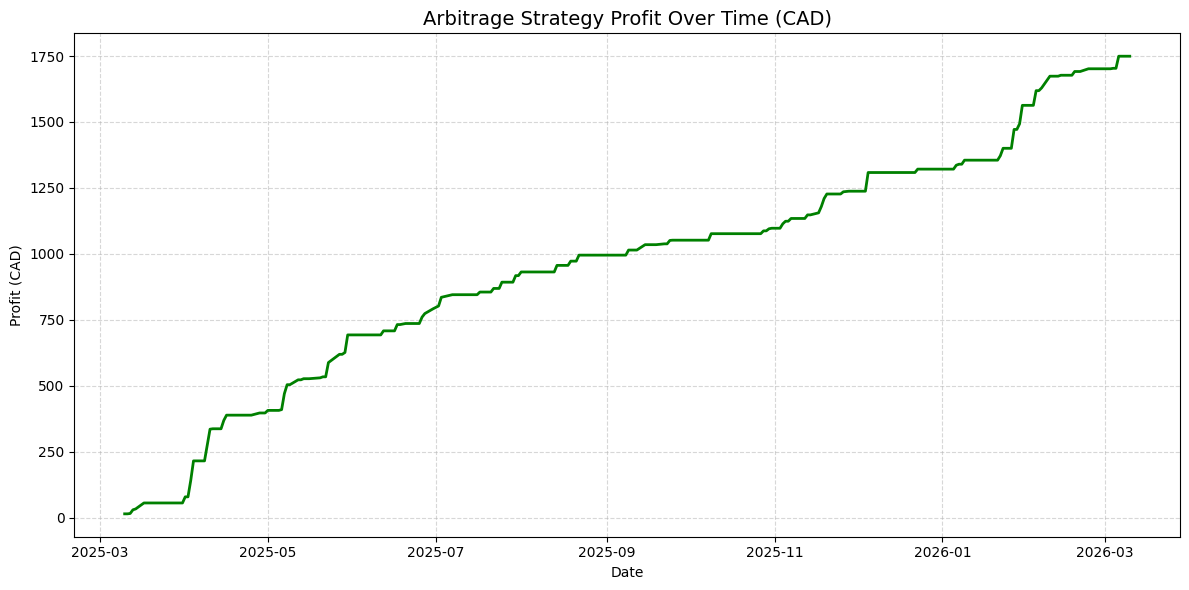

In [16]:
# 8) Cell 7: Plot Profit Curve
plt.figure(figsize=(12, 6))
plt.plot(equity_df.index, equity_df["Profit"], color="green", linewidth=2)
plt.title("Arbitrage Strategy Profit Over Time (CAD)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Profit (CAD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# 9) Cell 8: Optional Parameter Sweep (fees/spread threshold)
spread_grid = [0.0000, 0.0005, 0.0010, 0.0020, 0.0030]
cad_fee_grid = [20, 30, 40]

results = []
for s in spread_grid:
    for fee in cad_fee_grid:
        eq = buy_sell_compounding(
            merged_portfolio,
            initial_capital=initial_capital,
            cad_fee=fee,
            usd_fee_rate=usd_fee_rate,
            min_rel_spread=s
        )
        results.append({
            "min_rel_spread": s,
            "cad_fee": fee,
            "final_equity": eq["Equity"].iloc[-1],
            "total_profit": eq["Profit"].iloc[-1],
            "trades_executed": int(eq["TradesExecuted"].sum())
        })

sensitivity_df = pd.DataFrame(results).sort_values(
    by=["total_profit", "trades_executed"],
    ascending=[False, False]
)

display(sensitivity_df)

,min_rel_spread,cad_fee,final_equity,total_profit,trades_executed
0,0.0000,20,13014.253479,3014.253479,126
3,0.0005,20,13014.253479,3014.253479,126
6,0.0010,20,13014.253479,3014.253479,126
9,0.0020,20,13012.394620,3012.394620,124
12,0.0030,20,12725.563658,2725.563658,81
1,0.0000,30,11749.203775,1749.203775,82
4,0.0005,30,11749.203775,1749.203775,82
7,0.0010,30,11749.203775,1749.203775,82
10,0.0020,30,11749.203775,1749.203775,82
13,0.0030,30,11749.096201,1749.096201,80
